# 📉 Topic 3: PCA Part 3: Code and visualization

**Summary:** Applying PCA using scikit-learn for image compression and variance analysis.

---

## 📝 Core Concepts & Explanations

### Cumulative Explained Variance & Dimensionality Reduction
We evaluate how many components to keep by looking at the **Cumulative Explained Variance Ratio**. We can use PCA to compress high-dimensional images (like 64-pixel digits) into a tiny fraction of their original size while retaining visual structure.

## 💻 Code Demonstration
Run the cells below to see the concepts in action:

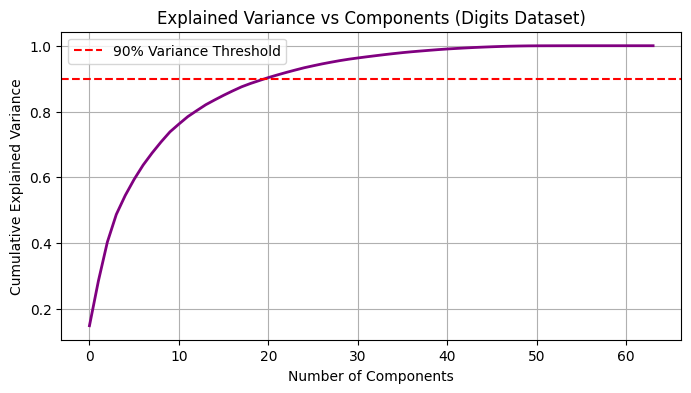

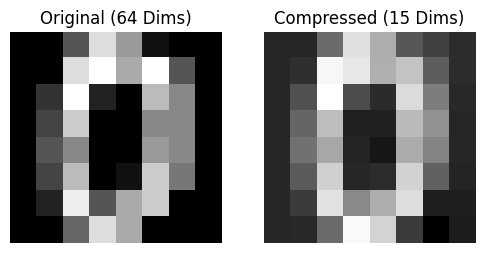

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA

# Load MNIST digits (8x8 images = 64 dimensions)
digits = load_digits()
X = digits.data

# Fit PCA without reducing dimensionality to see variance ratio
pca_full = PCA().fit(X)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(cumulative_variance, color='purple', linewidth=2)
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Variance Threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs Components (Digits Dataset)')
plt.legend()
plt.grid(True)
plt.show()

# Image Compression Example
pca_reduced = PCA(n_components=15) # Retain 15 dims out of 64
X_reduced = pca_reduced.fit_transform(X)
X_reconstructed = pca_reduced.inverse_transform(X_reduced)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(X[0].reshape(8, 8), cmap='gray')
axes[0].set_title('Original (64 Dims)')
axes[0].axis('off')

axes[1].imshow(X_reconstructed[0].reshape(8, 8), cmap='gray')
axes[1].set_title('Compressed (15 Dims)')
axes[1].axis('off')
plt.show()


### Exercises
1. Explain why `pca.inverse_transform()` yields an image that looks slightly blurry compared to the original.

In [2]:
print('The inverse transform attempts to reconstruct the 64-pixel image using only the 15 retained principal components. The blurry artifacts represent the information (variance) that was permanently discarded in the other 49 components.')


The inverse transform attempts to reconstruct the 64-pixel image using only the 15 retained principal components. The blurry artifacts represent the information (variance) that was permanently discarded in the other 49 components.
